# Лабораторна робота №2: Baseline Classification Pipeline (Decision Tree + Home Credit)

**Мета:** відтворити базовий життєвий цикл машинного навчання для задачі класифікації: підготувати дані, розділити їх на навчальну та валідаційну вибірки, навчити модель, оцінити її якість та сформувати прогноз для тестових даних.

**Задача:** за анкетою позичальника передбачити, чи матиме він труднощі з поверненням кредиту (`TARGET = 1` — труднощі з виплатами, `TARGET = 0` — усе інше). Дані — змагання Kaggle [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk/data); використано лише таблиці `application_train.csv` та `application_test.csv`.

**Бібліотеки:** numpy, pandas, matplotlib, scikit-learn (DecisionTreeClassifier, train_test_split, ROC-AUC, confusion matrix)

**Що навмисно не робиться** (згідно з умовою): детальний EDA, створення нових ознак, підбір гіперпараметрів, порівняння кількох алгоритмів.

---

## 1. Завантаження даних

In [1]:
# Імпорт модуля os для роботи зі шляхами до файлів даних
import os

# Імпорт модуля time для вимірювання часу навчання моделі
import time

# Імпорт бібліотеки NumPy для роботи з масивами
import numpy as np

# Імпорт бібліотеки Pandas для роботи з табличними даними
import pandas as pd

# Імпорт модуля matplotlib.pyplot для побудови графіків
import matplotlib.pyplot as plt

# Імпорт бібліотеки scikit-learn (потрібна лише для виводу її версії)
import sklearn

# Імпорт функції розділення вибірки на навчальну та валідаційну частини
from sklearn.model_selection import train_test_split

# Імпорт інструментів обробки даних: заповнення пропусків, кодування категорій
# та об'єднання кроків обробки в один об'єкт
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

# Імпорт класифікатора — дерева рішень
from sklearn.tree import DecisionTreeClassifier

# Імпорт метрик якості: ROC-AUC, ROC-крива, матриця помилок
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

# Вмикаємо відображення графіків безпосередньо в ноутбуці
%matplotlib inline

# Єдине значення для генератора випадкових чисел — щоб результати відтворювалися
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Єдиний стиль оформлення графіків для всього ноутбука
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Виводимо версії бібліотек — фіксуємо оточення, в якому ноутбук був виконаний
print(f"NumPy:        {np.__version__}")
print(f"Pandas:       {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"Matplotlib:   {plt.matplotlib.__version__}")

NumPy:        2.5.3
Pandas:       3.0.6
scikit-learn: 1.9.1
Matplotlib:   3.11.2


In [2]:
# --- Завантаження application_train.csv та application_test.csv ---

# Список каталогів, у яких шукаємо файли даних.
# Такий перебір дозволяє виконати ноутбук без змін і локально, і в Google Colab, і на Kaggle.
SEARCH_DIRS = [
    'data',                                       # локальний запуск: файли у підкаталозі ./data
    '.',                                          # файли лежать поруч із ноутбуком
    '/content',                                   # Google Colab: файли завантажені у сесію
    '/kaggle/input/home-credit-default-risk',     # Kaggle: дані змагання
]


def find_file(filename):
    """Повертає шлях до файлу даних, знайденого в одному з каталогів SEARCH_DIRS."""
    # Послідовно перебираємо каталоги-кандидати
    for d in SEARCH_DIRS:
        path = os.path.join(d, filename)
        # Якщо файл існує — повертаємо перший знайдений шлях
        if os.path.exists(path):
            return path
    # Якщо ніде не знайшли — повідомляємо зрозумілою помилкою
    raise FileNotFoundError(
        f"Не знайдено {filename}. Покладіть файл в один із каталогів: {SEARCH_DIRS}"
    )


# Читаємо навчальну таблицю (є колонка TARGET) та тестову (колонки TARGET немає)
train = pd.read_csv(find_file('application_train.csv'))
test = pd.read_csv(find_file('application_test.csv'))

# Виводимо розміри таблиць
print(f"application_train: {train.shape[0]} рядків, {train.shape[1]} колонок")
print(f"application_test:  {test.shape[0]} рядків, {test.shape[1]} колонок")

# Колонки, які є в train, але відсутні в test — очікуємо лише цільову змінну
print("\nКолонки, яких немає в test:", sorted(set(train.columns) - set(test.columns)))

application_train: 307511 рядків, 122 колонок
application_test:  48744 рядків, 121 колонок

Колонки, яких немає в test: ['TARGET']


Розподіл класів у application_train:
  TARGET = 0 (повертає кредит без проблем):  282686 рядків, 91.93 %
  TARGET = 1 (має труднощі з виплатами):   24825 рядків, 8.07 %

Якби модель завжди відповідала «0», її accuracy становила б 0.9193


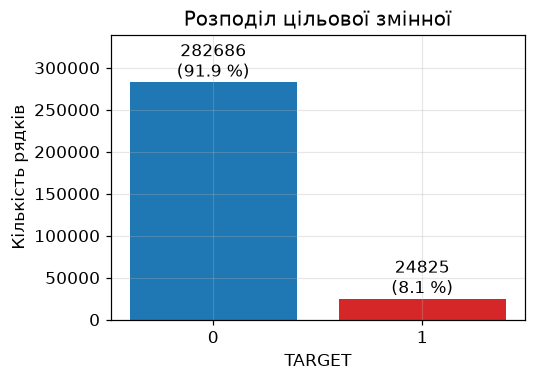

In [3]:
# --- Розподіл цільової змінної ---

# Кількість та частка рядків кожного класу
class_counts = train['TARGET'].value_counts().sort_index()
class_share = train['TARGET'].value_counts(normalize=True).sort_index()

print("Розподіл класів у application_train:")
for cls in class_counts.index:
    name = 'повертає кредит без проблем' if cls == 0 else 'має труднощі з виплатами'
    print(f"  TARGET = {cls} ({name}): {class_counts[cls]:>7d} рядків, {class_share[cls] * 100:.2f} %")

# Accuracy тривіальної моделі, яка завжди відповідає класом-більшістю.
# З нею порівнюватимемо accuracy справжньої моделі.
majority_share = class_share.max()
print(f"\nЯкби модель завжди відповідала «0», її accuracy становила б {majority_share:.4f}")

# Стовпчаста діаграма розподілу класів
fig, ax = plt.subplots(figsize=(5, 3.6))
ax.bar(['0', '1'], class_counts.values, color=['#1f77b4', '#d62728'])
for i, v in enumerate(class_counts.values):
    ax.text(i, v, f"{v}\n({class_share.values[i] * 100:.1f} %)", ha='center', va='bottom')
ax.set_ylim(0, class_counts.max() * 1.2)
ax.set_xlabel('TARGET')
ax.set_ylabel('Кількість рядків')
ax.set_title('Розподіл цільової змінної')
plt.tight_layout()
plt.show()

In [4]:
# --- Пропущені значення (лише масштаб проблеми, без детального EDA) ---

# Частка пропусків у кожній ознаці (цільову змінну не враховуємо)
missing_share = train.drop(columns=['TARGET']).isna().mean().sort_values(ascending=False)

print(f"Колонок із пропусками: {(missing_share > 0).sum()} з {len(missing_share)}")
print(f"Колонок, де пропущено понад 50 % значень: {(missing_share > 0.5).sum()}")

# Найбільша частка пропусків
print("\nКолонки з найбільшою часткою пропусків:")
for name, share in missing_share.head(5).items():
    print(f"  {name:<32} {share * 100:5.1f} %")

Колонок із пропусками: 67 з 121
Колонок, де пропущено понад 50 % значень: 41

Колонки з найбільшою часткою пропусків:
  COMMONAREA_AVG                    69.9 %
  COMMONAREA_MEDI                   69.9 %
  COMMONAREA_MODE                   69.9 %
  NONLIVINGAPARTMENTS_AVG           69.4 %
  NONLIVINGAPARTMENTS_MEDI          69.4 %


## 2. Відокремлення цільової змінної від ознак

- `y` — цільова змінна `TARGET`, яку модель має передбачати;
- `X` — усі інші колонки, **крім `SK_ID_CURR`**. Це лише ідентифікатор заявки: він не описує позичальника, і якщо залишити його серед ознак, дерево може почати «запам'ятовувати» конкретні номери замість закономірностей. Ідентифікатори тестових рядків зберігаємо окремо — вони потрібні для файлу submission.

In [5]:
# --- Відокремлення цільової змінної від ознак ---

# Цільова змінна — те, що прогнозуємо
y = train['TARGET']

# Ознаки навчальної таблиці: без цільової змінної та без ідентифікатора
X = train.drop(columns=['TARGET', 'SK_ID_CURR'])

# Ознаки тестової таблиці: без ідентифікатора (цільової змінної там і так немає)
X_test = test.drop(columns=['SK_ID_CURR'])

# Ідентифікатори тестових рядків зберігаємо для файлу submission
test_ids = test['SK_ID_CURR']

# Перевіряємо, що набір і порядок ознак у train та test однакові
assert list(X.columns) == list(X_test.columns), "Колонки train і test не збігаються"

print(f"Ознак для навчання: {X.shape[1]}")
print(f"Рядків у X: {X.shape[0]}, у y: {len(y)}, у X_test: {X_test.shape[0]}")

Ознак для навчання: 120
Рядків у X: 307511, у y: 307511, у X_test: 48744


## 3. Розділення на навчальну та валідаційну вибірки

Файл `application_test.csv` не містить відповідей (`TARGET`), тому оцінити якість моделі на ньому локально неможливо — оцінку можна отримати лише на Kaggle. Щоб мати власну оцінку, відкладаємо частину розмічених даних — **валідаційну вибірку**, яку модель під час навчання не бачить.

- `test_size=0.2` — класичне співвідношення 80/20: навчальної вибірки лишається багато, а валідаційна достатньо велика для стабільної оцінки;
- `stratify=y` — класи сильно незбалансовані (див. розподіл вище). Стратифікація зберігає однакову частку класу 1 в обох частинах, тож валідація не виявиться випадково «без дефолтів» або з їх надлишком;
- `random_state=42` — фіксує випадкове розбиття, і результат можна відтворити.

**Порядок кроків.** В умові «базова обробка» перелічена перед розділенням, але саму обробку виконуємо вже **після** розділення. Причина: медіани для заповнення пропусків та перелік категорій обчислюються за даними. Якби ми порахували їх по всьому train, у валідацію потрапила б інформація про її власні значення (витік даних, *data leakage*), і оцінка вийшла б завищеною. Тому параметри обробки «вчимо» лише на навчальній частині, а потім застосовуємо їх до валідації та до test.

In [6]:
# --- Розділення на навчальну та валідаційну вибірки ---

# train_test_split випадково ділить дані на дві частини
#   test_size=0.2      — 20 % рядків піде у валідацію
#   stratify=y         — зберігаємо однакову частку класів в обох частинах
#   random_state       — фіксуємо розбиття для відтворюваності
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Розміри та частка класу 1 у кожній частині
print(f"Навчальна вибірка:   {X_train.shape[0]:>7d} рядків, частка класу 1: {y_train.mean() * 100:.2f} %")
print(f"Валідаційна вибірка: {X_val.shape[0]:>7d} рядків, частка класу 1: {y_val.mean() * 100:.2f} %")

Навчальна вибірка:    246008 рядків, частка класу 1: 8.07 %
Валідаційна вибірка:   61503 рядків, частка класу 1: 8.07 %


## 4. Базова обробка даних

Дерево рішень у scikit-learn не вміє працювати з пропусками та текстовими значеннями, тому потрібні два кроки:

1. **Пропущені значення.**
   - *Числові ознаки* заповнюємо **медіаною** навчальної вибірки: вона, на відміну від середнього, майже не залежить від викидів.
   - *Категоріальні ознаки* заповнюємо окремою категорією **`Unknown`**: сам факт, що значення не вказане, може нести інформацію про позичальника, тому не підміняємо його найчастішою категорією.
2. **Кодування категорій — one-hot.** Кожна категорія стає окремою колонкою з 0/1. Мітки 0, 1, 2… (label encoding) вигадали б між категоріями порядок, якого в даних немає (наприклад, між типами організацій). Параметр `handle_unknown='ignore'` потрібен, щоб категорія, яка зустрілась лише у валідації чи test, не ламала обробку.

Ознаки не масштабуємо: дерево порівнює значення з порогами, тому масштаб на нього не впливає.

In [7]:
# --- Базова обробка: заповнення пропусків та кодування категорій ---

# Розділяємо ознаки за типом: числові та категоріальні (текстові)
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(exclude='number').columns.tolist()
print(f"Числових ознак:       {len(numeric_cols)}")
print(f"Категоріальних ознак: {len(categorical_cols)}")

# Обробка числових ознак: пропуски заповнюємо медіаною
numeric_pipeline = SimpleImputer(strategy='median')

# Обробка категоріальних ознак: пропуски -> категорія "Unknown", потім one-hot кодування
categorical_pipeline = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='Unknown'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False),
)

# Об'єднуємо обидва кроки: кожен застосовується до своєї групи колонок
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols),
])

# fit_transform на навчальній частині: тут обчислюються медіани та перелік категорій
X_train_prep = preprocessor.fit_transform(X_train)

# transform на валідації та test: застосовуємо ВЖЕ знайдені параметри, нічого не перераховуючи
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

# Підсумок обробки
print(f"\nОзнак після обробки: {X_train_prep.shape[1]} (було {X_train.shape[1]})")
print(f"Форма навчальної матриці:   {X_train_prep.shape}")
print(f"Форма валідаційної матриці: {X_val_prep.shape}")
print(f"Форма тестової матриці:     {X_test_prep.shape}")

# Перевіряємо, що пропусків у жодній з матриць не лишилось
print(f"\nПропусків після обробки: train = {np.isnan(X_train_prep).sum()}, "
      f"val = {np.isnan(X_val_prep).sum()}, test = {np.isnan(X_test_prep).sum()}")

Числових ознак:       104
Категоріальних ознак: 16



Ознак після обробки: 250 (було 120)
Форма навчальної матриці:   (246008, 250)
Форма валідаційної матриці: (61503, 250)
Форма тестової матриці:     (48744, 250)

Пропусків після обробки: train = 0, val = 0, test = 0


## 5. Навчання дерева рішень

Навчаємо `DecisionTreeClassifier` із **параметрами за замовчуванням**: `criterion='gini'`, `max_depth=None` (дерево росте, доки листи не стануть чистими), `min_samples_split=2`, `min_samples_leaf=1`. Гіперпараметри не підбираємо — так вимагає умова.

Єдиний явно заданий параметр — `random_state=42`. Він не змінює алгоритм: дерево лише використовує випадковість, щоб обрати між однаково добрими розбиттями, і фіксоване значення робить результат відтворюваним.

In [8]:
# --- Навчання дерева рішень ---

# Створюємо модель з параметрами за замовчуванням
# (random_state лише фіксує вибір між однаково добрими розбиттями)
model = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Навчаємо модель на навчальній частині та вимірюємо час
start = time.time()
model.fit(X_train_prep, y_train)
elapsed = time.time() - start

# Характеристики вирощеного дерева
print(f"Час навчання: {elapsed:.1f} с")
print(f"Глибина дерева:    {model.get_depth()}")
print(f"Кількість листів:  {model.get_n_leaves()}")
print(f"Рядків у навчальній вибірці: {X_train_prep.shape[0]}")

# Параметри моделі: переконуємось, що всі, крім random_state, — за замовчуванням
print("\nПараметри моделі:")
for name, value in model.get_params().items():
    print(f"  {name:<26} {value}")

Час навчання: 28.3 с
Глибина дерева:    62
Кількість листів:  19910
Рядків у навчальній вибірці: 246008

Параметри моделі:
  ccp_alpha                  0.0
  class_weight               None
  criterion                  gini
  max_depth                  None
  max_features               None
  max_leaf_nodes             None
  min_impurity_decrease      0.0
  min_samples_leaf           1
  min_samples_split          2
  min_weight_fraction_leaf   0.0
  monotonic_cst              None
  random_state               42
  splitter                   best


## 6. Оцінка якості: ROC-AUC

**ROC-AUC** оцінює, наскільки добре модель *впорядковує* позичальників за ризиком, і не залежить від порога, за яким ймовірність перетворюється на відповідь «0» чи «1». Значення 0.5 — це випадкове вгадування, 1.0 — ідеальне впорядкування.

Для розрахунку потрібні **ймовірності класу 1** (`predict_proba`), а не готові мітки: за мітками можна було б побудувати лише одну точку ROC-кривої. Саме ймовірності ми потім відправимо й на Kaggle.

Метрику рахуємо і на навчальній, і на валідаційній вибірці. Розрив між ними показує, чи модель справді навчилась узагальнювати.

ROC-AUC на навчальній вибірці:   1.0000
ROC-AUC на валідаційній вибірці: 0.5382
Розрив між ними: 0.4618

Різних значень ймовірності на валідації: 2
Частка прогнозів, де ймовірність рівно 0 або 1: 100.0 %


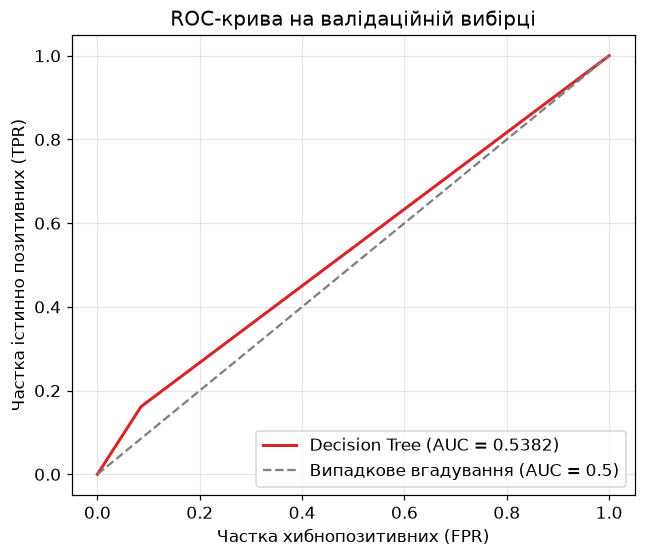

In [9]:
# --- ROC-AUC на навчальній та валідаційній вибірках ---

# Ймовірності класу 1 (колонка з індексом 1) для обох вибірок
train_proba = model.predict_proba(X_train_prep)[:, 1]
val_proba = model.predict_proba(X_val_prep)[:, 1]

# ROC-AUC: порівнюємо справжні мітки з ймовірностями
train_auc = roc_auc_score(y_train, train_proba)
val_auc = roc_auc_score(y_val, val_proba)

print(f"ROC-AUC на навчальній вибірці:   {train_auc:.4f}")
print(f"ROC-AUC на валідаційній вибірці: {val_auc:.4f}")
print(f"Розрив між ними: {train_auc - val_auc:.4f}")

# Скільки різних значень ймовірності видає дерево і яка частка з них — рівно 0 або 1
distinct_values = np.unique(val_proba)
share_extreme = np.mean((val_proba == 0) | (val_proba == 1))
print(f"\nРізних значень ймовірності на валідації: {len(distinct_values)}")
print(f"Частка прогнозів, де ймовірність рівно 0 або 1: {share_extreme * 100:.1f} %")

# ROC-крива валідаційної вибірки
fpr, tpr, _ = roc_curve(y_val, val_proba)
plt.figure(figsize=(6, 5.2))
plt.plot(fpr, tpr, color='#d62728', linewidth=2, label=f'Decision Tree (AUC = {val_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Випадкове вгадування (AUC = 0.5)')
plt.xlabel('Частка хибнопозитивних (FPR)')
plt.ylabel('Частка істинно позитивних (TPR)')
plt.title('ROC-крива на валідаційній вибірці')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Матриця помилок (Confusion Matrix)

Матриця помилок рахується для **жорстких міток** — тут використовуємо стандартний поріг 0.5 (`model.predict`). Для кредитної задачі клітинки мають такий зміст:

| | Модель сказала «0» | Модель сказала «1» |
|---|---|---|
| **Насправді 0** (поверне) | TN — правильно | **FP** — відмовили надійному клієнтові |
| **Насправді 1** (дефолт) | **FN** — пропустили ненадійного | TP — правильно |

Помилки FN і FP коштують по-різному: FN — це безповоротні втрати за кредитом, FP — недоотриманий прибуток.

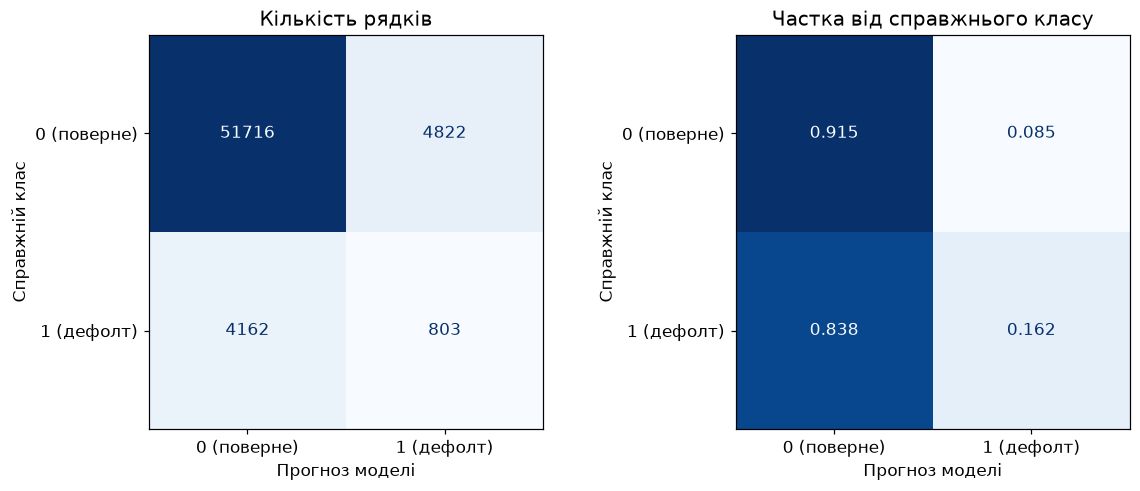

TN = 51716, FP = 4822, FN = 4162, TP = 803

Accuracy:    0.8539   (завжди «0» дало б 0.9193)
Precision:   0.1428   (серед тих, кого модель назвала дефолтом, скільки справді)
Recall:      0.1617   (скільки справжніх дефолтів модель знайшла)
Specificity: 0.9147   (скільки надійних клієнтів модель правильно пропустила)


In [10]:
# --- Матриця помилок на валідаційній вибірці ---

# Жорсткі мітки (0 або 1) за порогом 0.5
val_pred = model.predict(X_val_prep)

# Матриця помилок: рядки — справжні класи, стовпці — прогнози
cm = confusion_matrix(y_val, val_pred)
tn, fp, fn, tp = cm.ravel()

# Дві панелі: абсолютні числа та частки від справжнього класу (по рядках)
labels = ['0 (поверне)', '1 (дефолт)']
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=axes[0], cmap='Blues', colorbar=False, values_format='d')
axes[0].set_title('Кількість рядків')
axes[0].grid(False)

ConfusionMatrixDisplay(confusion_matrix(y_val, val_pred, normalize='true'), display_labels=labels).plot(
    ax=axes[1], cmap='Blues', colorbar=False, values_format='.3f')
axes[1].set_title('Частка від справжнього класу')
axes[1].grid(False)

# Українські підписи осей замість стандартних англійських
for ax in axes:
    ax.set_xlabel('Прогноз моделі')
    ax.set_ylabel('Справжній клас')

plt.tight_layout()
plt.show()

# Метрики, що випливають з матриці помилок
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}\n")
print(f"Accuracy:    {accuracy:.4f}   (завжди «0» дало б {majority_share:.4f})")
print(f"Precision:   {precision:.4f}   (серед тих, кого модель назвала дефолтом, скільки справді)")
print(f"Recall:      {recall:.4f}   (скільки справжніх дефолтів модель знайшла)")
print(f"Specificity: {specificity:.4f}   (скільки надійних клієнтів модель правильно пропустила)")

## 8. Аналіз помилок (Error Analysis)

Спочатку дивимось, з яких помилок складається результат, а потім — які ознаки модель використовує найбільше.

In [11]:
# --- Структура помилок ---

# Загальна кількість помилок та внесок кожного типу
total_errors = fp + fn
print(f"Усього помилок: {total_errors} із {len(y_val)} ({total_errors / len(y_val) * 100:.2f} %)")
print(f"  FP (відмовили надійному): {fp:>6d}  — {fp / total_errors * 100:5.1f} % усіх помилок")
print(f"  FN (пропустили дефолт):   {fn:>6d}  — {fn / total_errors * 100:5.1f} % усіх помилок")

# Помилки відносно розміру свого класу
print(f"\nЧастка пропущених дефолтів серед усіх справжніх дефолтів: {fn / (fn + tp) * 100:.1f} %")
print(f"Частка хибних відмов серед усіх надійних клієнтів:         {fp / (fp + tn) * 100:.1f} %")

# Скільки справжніх дефолтів у валідації та наскільки Precision перевищує базову частку дефолтів
print(f"\nСправжніх дефолтів у валідації: {fn + tp}")
print(f"Precision / базова частка дефолтів = {precision:.4f} / {y_val.mean():.4f} = {precision / y_val.mean():.2f}")

# Якість ранжування: порівнюємо AUC на навчальній вибірці та валідації
print(f"\nROC-AUC: навчальна {train_auc:.4f} -> валідаційна {val_auc:.4f}")

Усього помилок: 8984 із 61503 (14.61 %)
  FP (відмовили надійному):   4822  —  53.7 % усіх помилок
  FN (пропустили дефолт):     4162  —  46.3 % усіх помилок

Частка пропущених дефолтів серед усіх справжніх дефолтів: 83.8 %
Частка хибних відмов серед усіх надійних клієнтів:         8.5 %

Справжніх дефолтів у валідації: 4965
Precision / базова частка дефолтів = 0.1428 / 0.0807 = 1.77

ROC-AUC: навчальна 1.0000 -> валідаційна 0.5382


Топ-10 ознак за важливістю:
  EXT_SOURCE_2                       0.0687
  EXT_SOURCE_3                       0.0569
  DAYS_ID_PUBLISH                    0.0449
  DAYS_BIRTH                         0.0429
  DAYS_REGISTRATION                  0.0401
  DAYS_LAST_PHONE_CHANGE             0.0362
  EXT_SOURCE_1                       0.0339
  DAYS_EMPLOYED                      0.0339
  AMT_ANNUITY                        0.0328
  AMT_INCOME_TOTAL                   0.0293

Частка важливості, яку дають ці 10 ознак: 42.0 %
Ознак з нульовою важливістю (дерево їх не використало): 11 із 250


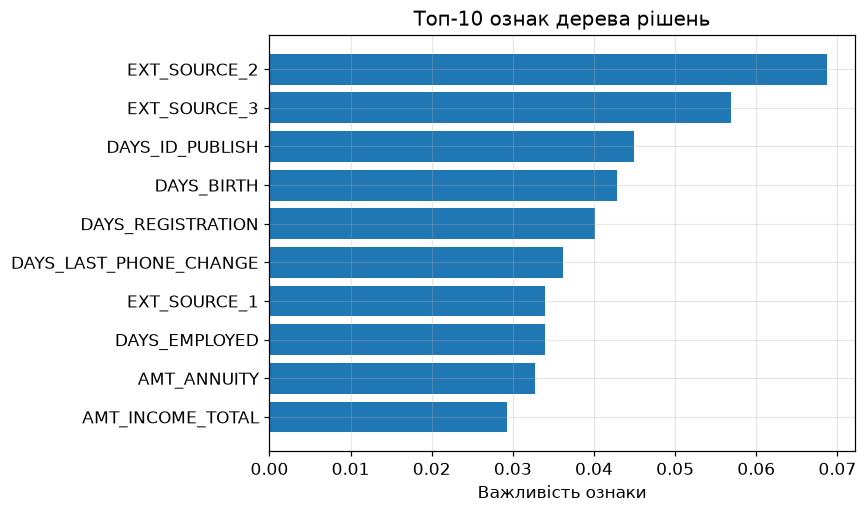

In [12]:
# --- Які ознаки найбільше використовує дерево ---

# Назви ознак після обробки (для one-hot колонок — "категорія_значення")
feature_names = preprocessor.get_feature_names_out()
# Прибираємо технічні префікси "num__" та "cat__"
feature_names = [n.split('__', 1)[1] for n in feature_names]

# Важливість ознак — внесок кожної в зменшення неоднорідності (gini) по всьому дереву
importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)

# Топ-10 ознак
top = importances.head(10)
print("Топ-10 ознак за важливістю:")
for name, value in top.items():
    print(f"  {name:<34} {value:.4f}")
print(f"\nЧастка важливості, яку дають ці 10 ознак: {top.sum() * 100:.1f} %")
print(f"Ознак з нульовою важливістю (дерево їх не використало): {(importances == 0).sum()} із {len(importances)}")

# Горизонтальна діаграма
plt.figure(figsize=(8, 4.8))
plt.barh(top.index[::-1], top.values[::-1], color='#1f77b4')
plt.xlabel('Важливість ознаки')
plt.title('Топ-10 ознак дерева рішень')
plt.tight_layout()
plt.show()

### Що показує аналіз помилок

**1. Accuracy тут вводить в оману.** Модель правильна у 85.39 % випадків, але проста відповідь «завжди 0» була б правильною у 91.93 %. За accuracy дерево гірше, ніж «нічого не робити»: надійних клієнтів 92 %, а модель помиляється в обох класах. Тому якість оцінюємо за ROC-AUC та матрицею помилок, а не за accuracy.

**2. Модель пропускає майже всіх ненадійних.** Із 4965 справжніх дефолтів знайдено лише 803 (recall 16.17 %), тобто 83.8 % пропущено (FN = 4162). Водночас 4822 надійним клієнтам модель хибно відмовила (FP), це 8.5 % усіх надійних. Precision становить 14.28 % проти базової частки дефолтів 8.07 %: серед тих, кого модель назвала дефолтом, їх у 1.77 раза більше, ніж у середньому. Отже, сигнал є, але дуже слабкий.

**3. Головна причина — перенавчання.** ROC-AUC на навчальній вибірці дорівнює 1.0000, а на валідаційній 0.5382. Дерево без обмеження глибини виросло до глибини 62 і майже 20 тисяч листів: воно «запам'ятало» навчальні рядки, але закономірності, знайдені так, на нових даних не працюють. Це класичне перенавчання (лекція 4) — велика різниця між якістю на навчальній і на валідаційній вибірці.

**4. Чому ймовірності лише 0 і 1.** У повністю вирослому дереві листи чисті (у листі один клас), тому `predict_proba` видає на валідації лише два різні значення: рівно 0 або рівно 1. ROC-крива тоді має єдину проміжну точку, і AUC дорівнює середньому між recall та specificity: (0.1617 + 0.9147) / 2 = 0.5382, що збігається з обчисленим значенням. Тобто модель майже не ранжує клієнтів за ризиком, а лише ділить їх на два «кошики».

**5. Які ознаки використовує дерево.** Найважливіші — зовнішні скорингові оцінки `EXT_SOURCE_2`, `EXT_SOURCE_3`, `EXT_SOURCE_1` та ознаки часу `DAYS_*` (від публікації документа, віку, реєстрації, зміни телефону, працевлаштування), далі `AMT_ANNUITY` і `AMT_INCOME_TOTAL`. Це ознаки, логічно пов'язані з надійністю позичальника, тож дерево знаходить справжній сигнал. Проте топ-10 дають лише 42.0 % важливості, решта розсіяна по багатьох ознаках: неперервні ознаки з багатьма різними значеннями дозволяють глибокому дереву дробити вибірку майже до окремих рядків.

**Що могло б покращити результат** (у цій роботі не робимо, бо умова забороняє підбір гіперпараметрів і нові ознаки): обмеження глибини дерева або мінімального розміру листа проти перенавчання; `class_weight='balanced'` проти дисбалансу класів; інший поріг замість 0.5; ансамблі (випадковий ліс, градієнтний бустинг).

## 9. Прогноз для тестових даних та submission-файл

Класифікуємо `application_test.csv` навченою моделлю. У файл записуємо **ймовірність класу 1** (а не мітку 0/1) — саме так вимагає формат змагання, бо оцінка там теж ROC-AUC. Тестові дані обробляємо тим самим `preprocessor`, який навчився на навчальній частині.

In [13]:
# --- Прогноз для application_test.csv та формування submission.csv ---

# Ймовірності класу 1 для тестових рядків (тестові ознаки вже оброблені тим самим preprocessor)
test_proba = model.predict_proba(X_test_prep)[:, 1]

# Таблиця submission: ідентифікатор заявки та ймовірність
submission = pd.DataFrame({'SK_ID_CURR': test_ids.values, 'TARGET': test_proba})

# Зберігаємо у CSV без індексу
submission.to_csv('submission.csv', index=False)
print(f"Збережено submission.csv: {submission.shape[0]} рядків, колонки: {list(submission.columns)}")
print("\nПерші 5 рядків:")
print(submission.head().to_string(index=False))

# Перевірка формату за зразком sample_submission.csv (якщо файл поруч)
try:
    sample = pd.read_csv(find_file('sample_submission.csv'))
    same_columns = list(sample.columns) == list(submission.columns)
    same_rows = len(sample) == len(submission)
    same_ids = set(sample['SK_ID_CURR']) == set(submission['SK_ID_CURR'])
    print(f"\nЗбіг із sample_submission.csv: колонки — {same_columns}, "
          f"кількість рядків — {same_rows}, набір SK_ID_CURR — {same_ids}")
except FileNotFoundError:
    print("\nsample_submission.csv не знайдено — перевірку формату пропущено.")

Збережено submission.csv: 48744 рядків, колонки: ['SK_ID_CURR', 'TARGET']

Перші 5 рядків:
 SK_ID_CURR  TARGET
     100001     0.0
     100005     0.0
     100013     0.0
     100028     0.0
     100038     0.0

Збіг із sample_submission.csv: колонки — True, кількість рядків — True, набір SK_ID_CURR — True


## 10. Результат на Kaggle (Late Submission)

Файл `submission.csv` (48744 рядки: `SK_ID_CURR` та ймовірність класу 1) завантажено на Kaggle у розділ **Late Submission** змагання Home Credit Default Risk. Змагання завершилось у 2018 році, тому подання позначається як «після дедлайну» й у таблицю лідерів не потрапляє, але оцінку Kaggle рахує так само: за ROC-AUC на прихованих відповідях для `application_test.csv`.

Нижче знімок екрана з вкладки «Подання» (Submissions). Інтерфейс Kaggle українською, тому на знімку десяткова частина записана комою.

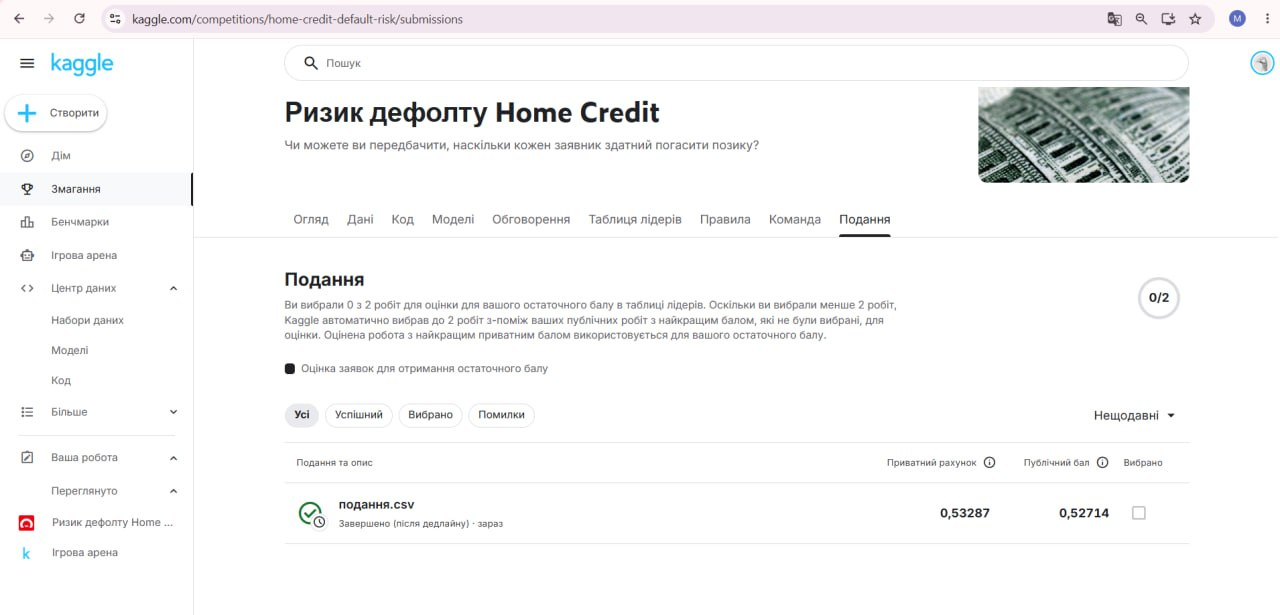

In [14]:
# --- Знімок екрана з результатом на Kaggle ---

# Імпорт засобів для показу зображення в ноутбуці
from IPython.display import Image, display

# Знімок лежить у підкаталозі images/ поруч із ноутбуком
SCREENSHOT = os.path.join('images', 'kaggle_result.png')

if os.path.exists(SCREENSHOT):
    # Показуємо знімок вкладки "Подання" з оцінками Public та Private
    display(Image(filename=SCREENSHOT, width=950))
else:
    print(f"Знімок {SCREENSHOT} не знайдено: покладіть його в підкаталог images/.")

### Порівняння оцінок

На знімку: **Публічний бал (Public score) = 0.52714**, **Приватний рахунок (Private score) = 0.53287**. Порівняємо їх із власною оцінкою на валідації:

| Де оцінено | ROC-AUC |
|---|---|
| Валідаційна вибірка (20 % application_train) | 0.5382 |
| Kaggle, Public score | 0.52714 |
| Kaggle, Private score | 0.53287 |

Усі три значення лежать поруч, приблизно 0.53. Це підтверджує, що власна валідація була чесною (витоку даних немає) і що дерево справді працює на рівні трохи вище випадкового вгадування, а не лише на нашому розбитті. Невелика різниця між Public і Private очікувана: Kaggle рахує їх на різних частинах тестової вибірки.

## Висновки

1. **Відтворено повний базовий життєвий цикл класифікації:** завантаження даних (307511 навчальних та 48744 тестових рядків, 120 ознак), відокремлення цільової змінної `TARGET` та ідентифікатора `SK_ID_CURR`, розділення на навчальну та валідаційну вибірки, обробка, навчання, оцінка, аналіз помилок і формування submission-файлу.

2. **Розділення виконано стратифіковано у співвідношенні 80/20** (246008 навчальних та 61503 валідаційних рядків), бо класи сильно незбалансовані: 91.93 % надійних позичальників проти 8.07 % ненадійних. Обробку «навчено» лише на навчальній частині, щоб уникнути витоку даних: пропуски в 104 числових ознаках заповнено медіаною, у 16 категоріальних — категорією `Unknown` з подальшим one-hot кодуванням. Після цього ознак стало 250.

3. **Якість моделі низька:** ROC-AUC на валідаційній вибірці становить **0.5382**, що лише трохи вище за 0.5 випадкового вгадування. На навчальній вибірці AUC дорівнює 1.0000. Така розбіжність означає, що дерево з параметрами за замовчуванням (глибина 62, 19910 листів) **перенавчилось**.

4. **Матриця помилок:** TN = 51716, FP = 4822, FN = 4162, TP = 803. Accuracy 0.8539 нижча за 0.9193 тривіальної відповіді «завжди 0», а recall становить лише 0.1617: модель пропускає 83.8 % справжніх дефолтів. Для кредитної задачі це найдорожча помилка, тож на accuracy тут орієнтуватися не можна.

5. **Причини низької якості:** перенавчання та дисбаланс класів. Чисті листи повністю вирослого дерева дають ймовірності лише 0 і 1, тому ROC-крива складається з однієї проміжної точки, а AUC дорівнює середньому recall і specificity ((0.1617 + 0.9147) / 2 = 0.5382). Найбільше дерево використовує `EXT_SOURCE_2`, `EXT_SOURCE_3`, `DAYS_ID_PUBLISH`, `DAYS_BIRTH`, але топ-10 ознак дають лише 42.0 % важливості.

6. **Submission сформовано:** для 48744 тестових рядків записано ймовірність класу 1 (а не жорстку мітку, бо метрика змагання теж ROC-AUC). Формат збігається з `sample_submission.csv`. Після завантаження на Kaggle (Late Submission) отримано **Public score 0.52714** та **Private score 0.53287**: це близько до валідаційних 0.5382, тож власна оцінка була чесною, а модель справді лише трохи краща за випадкове вгадування.

7. **Практична цінність.** Така модель непридатна для реального кредитного скорингу, але як **baseline** вона задає точку відліку: будь-яке покращення (обмеження глибини дерева, ваги класів, ансамблі) варто порівнювати з ROC-AUC 0.5382 на цій самій валідаційній вибірці.